In [116]:
!sudo apt install -y fluidsynth
!pip install pretty_midi
!pip install --upgrade pyfluidsynth

Reading package lists... Done
Building dependency tree... Done
Reading state information... Done
fluidsynth is already the newest version (2.2.5-1).
0 upgraded, 0 newly installed, 0 to remove and 41 not upgraded.


In [117]:
import collections
import datetime
import fluidsynth
import glob
import numpy as np
import pathlib
import pandas as pd
import pretty_midi
import seaborn as sns
import tensorflow as tf

from IPython import display
from matplotlib import pyplot as plt
from typing import Optional

In [118]:
seed = 42
tf.random.set_seed(seed)
np.random.seed(seed)

_SAMPLING_RATE = 16000

In [119]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [120]:
data_dir = pathlib.Path('/content/drive/MyDrive/Assignment 3 - music/midi_data')
filenames = glob.glob(str(data_dir/'*.mid'))
print('Number of files:', len(filenames))

Number of files: 93


In [121]:
sample_file = filenames[1]
print(sample_file)

/content/drive/MyDrive/Assignment 3 - music/midi_data/12.mid


In [122]:
pm = pretty_midi.PrettyMIDI(sample_file)

def display_audio(pm: pretty_midi.PrettyMIDI, seconds=30):
  waveform = pm.fluidsynth(fs=_SAMPLING_RATE)
  # Take a sample of the generated waveform to mitigate kernel resets
  waveform_short = waveform[:seconds*_SAMPLING_RATE]
  return display.Audio(waveform_short, rate=_SAMPLING_RATE)

In [123]:
display_audio(pm)

In [124]:
def midi_to_notes(midi_file: str) -> pd.DataFrame:
  pm = pretty_midi.PrettyMIDI(midi_file)
  instrument = pm.instruments[0]
  notes = collections.defaultdict(list)

  # Sort the notes by start time
  sorted_notes = sorted(instrument.notes, key=lambda note: note.start)
  prev_start = sorted_notes[0].start

  for note in sorted_notes:
    start = note.start
    end = note.end
    notes['pitch'].append(note.pitch)
    notes['start'].append(start)
    notes['end'].append(end)
    notes['step'].append(start - prev_start)
    notes['duration'].append(end - start)
    prev_start = start

  return pd.DataFrame({name: np.array(value) for name, value in notes.items()})

In [125]:
raw_notes = midi_to_notes(sample_file)
raw_notes.head()

,pitch,start,end,step,duration
0,41,0.005208,0.203125,0.0,0.197917
1,60,0.005208,0.203125,0.0,0.197917
2,65,0.005208,0.203125,0.0,0.197917
3,69,0.005208,0.203125,0.0,0.197917
4,76,0.005208,0.203125,0.0,0.197917


In [126]:
def plot_piano_roll(notes: pd.DataFrame):

  title = f'Whole track'
  count = len(notes['pitch'])
  plt.figure(figsize=(20, 4))
  plot_pitch = np.stack([notes['pitch'], notes['pitch']], axis=0)
  plot_start_stop = np.stack([notes['start'], notes['end']], axis=0)
  plt.plot(
      plot_start_stop[:, :count], plot_pitch[:, :count], color="b", marker=".")
  plt.xlabel('Time [s]')
  plt.ylabel('Pitch')
  _ = plt.title(title)

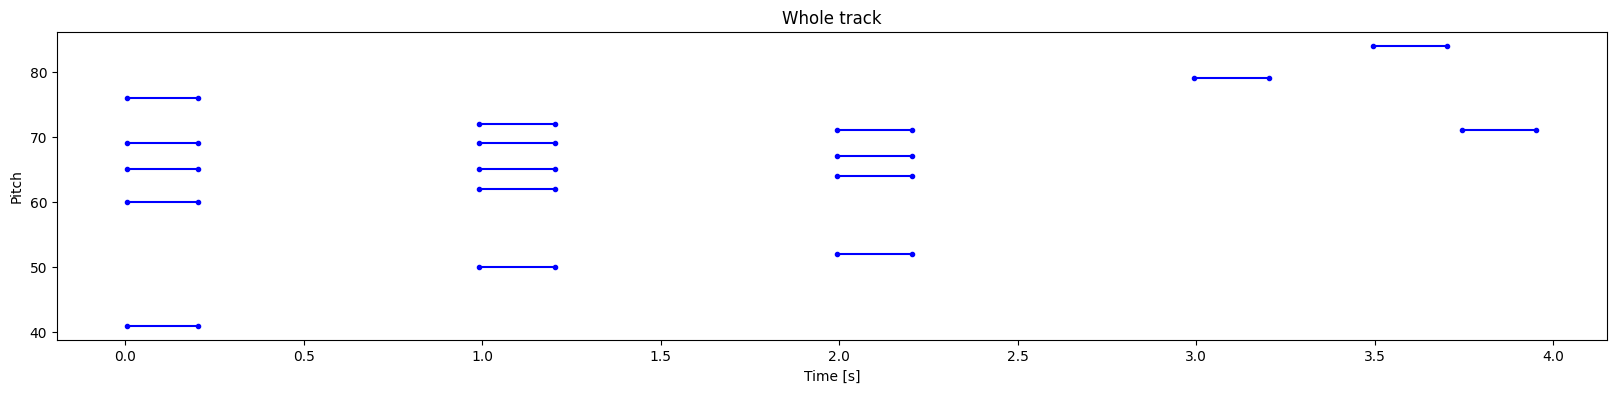

In [127]:
plot_piano_roll(raw_notes)

In [128]:
def plot_distributions(notes: pd.DataFrame, drop_percentile=2.5):
  plt.figure(figsize=[15, 5])
  plt.subplot(1, 3, 1)
  sns.histplot(notes, x="pitch", bins=20)

  plt.subplot(1, 3, 2)
  max_step = np.percentile(notes['step'], 100 - drop_percentile)
  sns.histplot(notes, x="step", bins=np.linspace(0, max_step, 21))

  plt.subplot(1, 3, 3)
  max_duration = np.percentile(notes['duration'], 100 - drop_percentile)
  sns.histplot(notes, x="duration", bins=np.linspace(0, max_duration, 21))

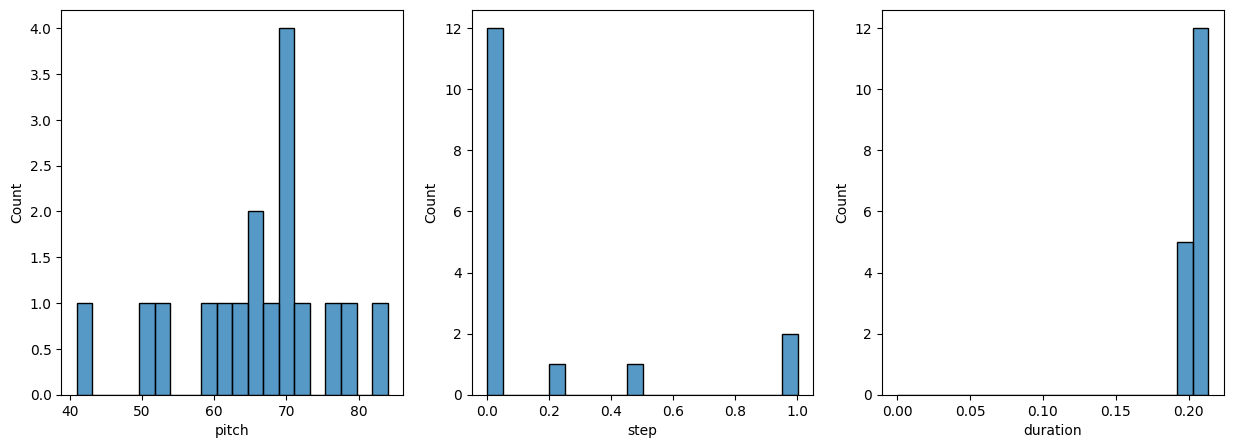

In [129]:
plot_distributions(raw_notes)

In [130]:
def notes_to_midi(
  notes: pd.DataFrame,
  out_file: str,
  instrument_name: str,
  velocity: int = 100,  # note loudness
) -> pretty_midi.PrettyMIDI:

  pm = pretty_midi.PrettyMIDI()
  instrument = pretty_midi.Instrument(
      program=pretty_midi.instrument_name_to_program(
          instrument_name))

  prev_start = 0
  for i, note in notes.iterrows():
    start = float(prev_start + note['step'])
    end = float(start + note['duration'])
    note = pretty_midi.Note(
        velocity=velocity,
        pitch=int(note['pitch']),
        start=start,
        end=end,
    )
    instrument.notes.append(note)
    prev_start = start

  pm.instruments.append(instrument)
  pm.write(out_file)
  return pm

In [131]:
all_notes = []
for f in filenames:
  notes = midi_to_notes(f)
  all_notes.append(notes)

all_notes = pd.concat(all_notes)

/usr/local/lib/python3.12/dist-packages/pretty_midi/pretty_midi.py:122: RuntimeWarning: Tempo, Key or Time signature change events found on non-zero tracks.  This is not a valid type 0 or type 1 MIDI file.  Tempo, Key or Time Signature may be wrong.
  warnings.warn(


In [132]:
n_notes = len(all_notes)
print('Number of notes parsed:', n_notes)

Number of notes parsed: 4060


In [133]:
key_order = ['pitch', 'step', 'duration']
train_notes = np.stack([all_notes[key] for key in key_order], axis=1)
notes_ds = tf.data.Dataset.from_tensor_slices(train_notes)
notes_ds.element_spec

TensorSpec(shape=(3,), dtype=tf.float64, name=None)

In [134]:
def create_sequences(
    dataset: tf.data.Dataset,
    seq_length: int,
    vocab_size = 128,
) -> tf.data.Dataset:
  """Returns TF Dataset of sequence and label examples."""
  seq_length = seq_length+1

  # Take 1 extra for the labels
  windows = dataset.window(seq_length, shift=1, stride=1,
                              drop_remainder=True)

  # `flat_map` flattens the" dataset of datasets" into a dataset of tensors
  flatten = lambda x: x.batch(seq_length, drop_remainder=True)
  sequences = windows.flat_map(flatten)

  # Normalize note pitch
  def scale_pitch(x):
    x = x/[vocab_size,1.0,1.0]
    return x

  # Split the labels
  def split_labels(sequences):
    inputs = sequences[:-1]
    labels_dense = sequences[-1]
    labels = {key:labels_dense[i] for i,key in enumerate(key_order)}

    return scale_pitch(inputs), labels

  return sequences.map(split_labels, num_parallel_calls=tf.data.AUTOTUNE)

In [135]:
seq_length = 25
vocab_size = 128
seq_ds = create_sequences(notes_ds, seq_length, vocab_size)


In [136]:
batch_size = 64
buffer_size = n_notes - seq_length  # the number of items in the dataset
train_ds = (seq_ds
            .shuffle(buffer_size)
            .batch(batch_size, drop_remainder=True)
            .cache()
            .prefetch(tf.data.experimental.AUTOTUNE))

In [137]:
input_shape = (seq_length, 3)
learning_rate = 0.005

inputs = tf.keras.Input(input_shape)
x = tf.keras.layers.LSTM(128)(inputs)

outputs = {
  'pitch': tf.keras.layers.Dense(128, name='pitch')(x),
  'step': tf.keras.layers.Dense(1, name='step')(x),
  'duration': tf.keras.layers.Dense(1, name='duration')(x),
}

model = tf.keras.Model(inputs, outputs)

loss = {
      'pitch': tf.keras.losses.SparseCategoricalCrossentropy(
          from_logits=True),
      'step': tf.keras.losses.MSE,
      'duration': tf.keras.losses.MSE,
}

optimizer = tf.keras.optimizers.Adam(learning_rate=learning_rate)

model.compile(loss=loss, optimizer=optimizer)

model.summary()

Model: "functional_4"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer_4       │ (None, 25, 3)     │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ lstm_5 (LSTM)       │ (None, 128)       │     67,584 │ input_layer_4[0]… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ duration (Dense)    │ (None, 1)         │        129 │ lstm_5[0][0]      │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ pitch (Dense)       │ (None, 128)       │     16,512 │ lstm_5[0][0]      │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ step (Dense)        │ (None, 1)         │        129 │ lstm_5[0][0]      │
└─────────────────────┴───────────────────┴────────────┴───────────────────┘

 Total params: 84,354 (329.51 KB)

 Trainable params: 84,354 (329.51 KB)

 Non-trainable params: 0 (0.00 B)

In [138]:
losses = model.evaluate(train_ds, return_dict=True)
losses

63/63 ━━━━━━━━━━━━━━━━━━━━ 10s 59ms/step - duration_loss: 1.0482 - loss: 6.0764 - pitch_loss: 4.8454 - step_loss: 0.1827


/usr/local/lib/python3.12/dist-packages/keras/src/trainers/epoch_iterator.py:160: UserWarning: Your input ran out of data; interrupting training. Make sure that your dataset or generator can generate at least `steps_per_epoch * epochs` batches. You may need to use the `.repeat()` function when building your dataset.
  self._interrupted_warning()


{'duration_loss': 1.0077680349349976,
 'loss': 5.957586765289307,
 'pitch_loss': 4.771646976470947,
 'step_loss': 0.1781727522611618}

In [139]:
model.compile(
    loss=loss,
    loss_weights={
        'pitch': 0.05,
        'step': 1.0,
        'duration':1.0,
    },
    optimizer=optimizer,
)
callbacks = [
   tf.keras.callbacks.EarlyStopping(
        monitor='loss',
        patience=5,
        verbose=1,
        restore_best_weights=True),
]

epochs = 50

history = model.fit(
    train_ds,
    epochs=epochs,
    callbacks=callbacks,
)

Epoch 1/50
63/63 ━━━━━━━━━━━━━━━━━━━━ 20s 129ms/step - duration_loss: 0.3594 - loss: 0.7424 - pitch_loss: 4.5887 - step_loss: 0.1536
Epoch 2/50
63/63 ━━━━━━━━━━━━━━━━━━━━ 7s 106ms/step - duration_loss: 0.2003 - loss: 0.5361 - pitch_loss: 3.9380 - step_loss: 0.1389
Epoch 3/50
63/63 ━━━━━━━━━━━━━━━━━━━━ 2s 31ms/step - duration_loss: 0.1961 - loss: 0.5219 - pitch_loss: 3.8455 - step_loss: 0.1336
Epoch 4/50
63/63 ━━━━━━━━━━━━━━━━━━━━ 2s 30ms/step - duration_loss: 0.1941 - loss: 0.5142 - pitch_loss: 3.8126 - step_loss: 0.1295
Epoch 5/50
63/63 ━━━━━━━━━━━━━━━━━━━━ 2s 30ms/step - duration_loss: 0.1926 - loss: 0.5080 - pitch_loss: 3.7926 - step_loss: 0.1258
Epoch 6/50
63/63 ━━━━━━━━━━━━━━━━━━━━ 3s 49ms/step - duration_loss: 0.1924 - loss: 0.5049 - pitch_loss: 3.7762 - step_loss: 0.1237
Epoch 7/50
63/63 ━━━━━━━━━━━━━━━━━━━━ 6s 97ms/step - duration_loss: 0.1915 - loss: 0.5018 - pitch_loss: 3.7604 - step_loss: 0.1222
Epoch 8/50
63/63 ━━━━━━━━━━━━━━━━━━━━ 2s 29ms/step - duration_loss: 0.1898 - los

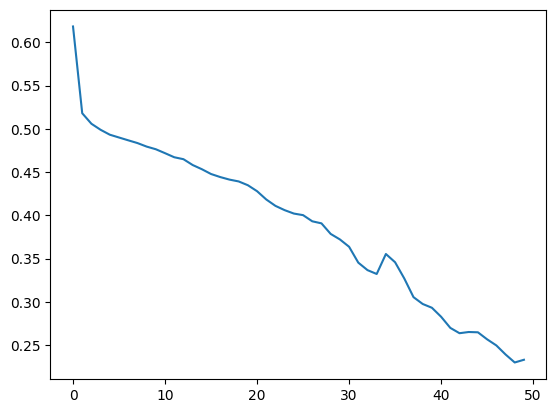

In [140]:
plt.plot(history.epoch, history.history['loss'], label='total loss')
plt.show()

In [141]:
def predict_next_note(
    notes: np.ndarray,
    model: tf.keras.Model,
    temperature: float = 1.0) -> tuple[int, float, float]:
  """Generates a note as a tuple of (pitch, step, duration), using a trained sequence model."""

  assert temperature > 0

  # Add batch dimension
  inputs = tf.expand_dims(notes, 0)

  predictions = model.predict(inputs)
  pitch_logits = predictions['pitch']
  step = predictions['step']
  duration = predictions['duration']

  pitch_logits /= temperature
  pitch = tf.random.categorical(pitch_logits, num_samples=1)
  pitch = tf.squeeze(pitch, axis=-1)
  duration = tf.squeeze(duration, axis=-1)
  step = tf.squeeze(step, axis=-1)

  # `step` and `duration` values should be non-negative
  step = tf.maximum(0, step)
  duration = tf.maximum(0, duration)

  return int(pitch), float(step), float(duration)

In [164]:
temperature = 0.05
num_predictions = 120

# Use train_notes to ensure enough length and correct scaling
input_notes = (train_notes[:seq_length] / np.array([vocab_size, 1, 1]))

generated_notes = []
prev_start = 0
for _ in range(num_predictions):
  pitch, step, duration = predict_next_note(input_notes, model, temperature)

  start = prev_start + step
  end = start + duration

  # Scale the new note before appending to maintain consistency
  scaled_input_note = np.array([pitch, step, duration]) / np.array([vocab_size, 1, 1])
  generated_notes.append((pitch, step, duration, start, end))

  # Update input_notes by removing the oldest and adding the new scaled note
  input_notes = np.delete(input_notes, 0, axis=0)
  input_notes = np.append(input_notes, np.expand_dims(scaled_input_note, 0), axis=0)
  prev_start = start

generated_notes = pd.DataFrame(
    generated_notes, columns=(*key_order, 'start', 'end'))

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 65ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 55ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 59ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 54ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 58ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 55ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 54ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 52ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 53ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 57ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 67ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 52ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 74ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 58ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 59ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 57ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 54ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 54ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 56ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 55ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 50ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 37ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 35ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 35ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 34ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 37ms/step
1/1 ━━━━━━━━

In [165]:
out_file = 'output_RNN_low_temperature.mid'
out_pm = notes_to_midi(
    generated_notes, out_file=out_file, instrument_name='Slap Bass 1')
display_audio(out_pm)

In [166]:
from google.colab import files
files.download(out_file)

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [145]:
# --- Simple LSTM Model (for next-note prediction) ---
import tensorflow as tf

input_shape = (seq_length, 3)
learning_rate = 0.005

inputs = tf.keras.Input(shape=input_shape)

# LSTM with return_sequences=True allows deeper temporal representation
x = tf.keras.layers.LSTM(64, return_sequences=True)(inputs)
x = tf.keras.layers.LSTM(64)(x)
x = tf.keras.layers.Dense(64, activation='relu')(x)

# Three outputs: pitch (classification), step & duration (regression)
outputs = {
    'pitch': tf.keras.layers.Dense(128, name='pitch')(x),
    'step': tf.keras.layers.Dense(1, name='step')(x),
    'duration': tf.keras.layers.Dense(1, name='duration')(x),
}

# Define model
lstm_model = tf.keras.Model(inputs, outputs)

# Compile with same loss setup
losses = {
    'pitch': tf.keras.losses.SparseCategoricalCrossentropy(from_logits=True),
    'step': tf.keras.losses.MeanSquaredError(),
    'duration': tf.keras.losses.MeanSquaredError(),
}

optimizer = tf.keras.optimizers.Adam(learning_rate=learning_rate)
lstm_model.compile(loss=losses, optimizer=optimizer)

lstm_model.summary()


Model: "functional_5"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer_5       │ (None, 25, 3)     │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ lstm_6 (LSTM)       │ (None, 25, 64)    │     17,408 │ input_layer_5[0]… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ lstm_7 (LSTM)       │ (None, 64)        │     33,024 │ lstm_6[0][0]      │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_3 (Dense)     │ (None, 64)        │      4,160 │ lstm_7[0][0]      │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ duration (Dense)    │ (None, 1)         │         65 │ dense_3[0][0]     │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ pitch (Dense)       │ (None, 128)       │      8,320 │ dense_3[0][0]     │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ step (Dense)        │ (None, 1)         │         65 │ dense_3[0][0]     │
└─────────────────────┴───────────────────┴────────────┴───────────────────┘

 Total params: 63,042 (246.26 KB)

 Trainable params: 63,042 (246.26 KB)

 Non-trainable params: 0 (0.00 B)

In [146]:
lstm_model.compile(
    loss=loss,
    loss_weights={
        'pitch': 0.05,
        'step': 1.0,
        'duration':1.0,
    },
    optimizer=optimizer,
)
callbacks = [
   tf.keras.callbacks.EarlyStopping(
        monitor='loss',
        patience=5,
        verbose=1,
        restore_best_weights=True),
]

history_ltsm = lstm_model.fit(
    train_ds,
    epochs=epochs,
    callbacks=callbacks,
)

Epoch 1/50
63/63 ━━━━━━━━━━━━━━━━━━━━ 5s 26ms/step - duration_loss: 0.3711 - loss: 0.7547 - pitch_loss: 4.5957 - step_loss: 0.1538
Epoch 2/50
63/63 ━━━━━━━━━━━━━━━━━━━━ 2s 26ms/step - duration_loss: 0.2130 - loss: 0.5548 - pitch_loss: 3.9356 - step_loss: 0.1450
Epoch 3/50
63/63 ━━━━━━━━━━━━━━━━━━━━ 2s 26ms/step - duration_loss: 0.2010 - loss: 0.5309 - pitch_loss: 3.8495 - step_loss: 0.1375
Epoch 4/50
63/63 ━━━━━━━━━━━━━━━━━━━━ 4s 57ms/step - duration_loss: 0.1977 - loss: 0.5207 - pitch_loss: 3.8284 - step_loss: 0.1316
Epoch 5/50
63/63 ━━━━━━━━━━━━━━━━━━━━ 7s 110ms/step - duration_loss: 0.1943 - loss: 0.5125 - pitch_loss: 3.8131 - step_loss: 0.1275
Epoch 6/50
63/63 ━━━━━━━━━━━━━━━━━━━━ 2s 26ms/step - duration_loss: 0.1912 - loss: 0.5064 - pitch_loss: 3.7983 - step_loss: 0.1253
Epoch 7/50
63/63 ━━━━━━━━━━━━━━━━━━━━ 2s 26ms/step - duration_loss: 0.1904 - loss: 0.5022 - pitch_loss: 3.7848 - step_loss: 0.1226
Epoch 8/50
63/63 ━━━━━━━━━━━━━━━━━━━━ 2s 25ms/step - duration_loss: 0.1892 - loss:

In [170]:
temperature = 4
num_predictions = 200

# Use train_notes to ensure enough length and correct scaling
input_notes = (train_notes[:seq_length] / np.array([vocab_size, 1, 1]))

generated_notes = []
prev_start = 0
for _ in range(num_predictions):
  pitch, step, duration = predict_next_note(input_notes, lstm_model, temperature)

  start = prev_start + step
  end = start + duration

  # Scale the new note before appending to maintain consistency
  scaled_input_note = np.array([pitch, step, duration]) / np.array([vocab_size, 1, 1])
  generated_notes.append((pitch, step, duration, start, end))

  # Update input_notes by removing the oldest and adding the new scaled note
  input_notes = np.delete(input_notes, 0, axis=0)
  input_notes = np.append(input_notes, np.expand_dims(scaled_input_note, 0), axis=0)
  prev_start = start

generated_notes = pd.DataFrame(
    generated_notes, columns=(*key_order, 'start', 'end'))

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 74ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 70ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 60ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 64ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 56ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 60ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 65ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 50ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 55ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 77ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 52ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 51ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 53ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 53ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 68ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 58ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 63ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 61ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 77ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 95ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 99ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 111ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 117ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 147ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 85ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 100ms/step
1/1 ━━━━

In [172]:
out_file = 'output_lstm_high.mid'
out_pm = notes_to_midi(
    generated_notes, out_file=out_file, instrument_name='Slap Bass 1')
display_audio(out_pm)

In [173]:
from google.colab import files
files.download(out_file)

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [150]:
# --- Simple GRU Model (for next-note prediction) ---
import tensorflow as tf

input_shape = (seq_length, 3)
learning_rate = 0.005

inputs = tf.keras.Input(shape=input_shape)

# Two stacked GRU layers — smaller but efficient
x = tf.keras.layers.GRU(64, return_sequences=True)(inputs)
x = tf.keras.layers.GRU(64)(x)
x = tf.keras.layers.Dense(64, activation='relu')(x)

# Three outputs: pitch (classification), step & duration (regression)
outputs = {
    'pitch': tf.keras.layers.Dense(128, name='pitch')(x),
    'step': tf.keras.layers.Dense(1, name='step')(x),
    'duration': tf.keras.layers.Dense(1, name='duration')(x),
}

# Build model
gru_model = tf.keras.Model(inputs, outputs)

# Compile with same structure as your other models
losses = {
    'pitch': tf.keras.losses.SparseCategoricalCrossentropy(from_logits=True),
    'step': tf.keras.losses.MeanSquaredError(),
    'duration': tf.keras.losses.MeanSquaredError(),
}

optimizer = tf.keras.optimizers.Adam(learning_rate=learning_rate)
gru_model.compile(loss=losses, optimizer=optimizer)

gru_model.summary()


Model: "functional_6"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer_6       │ (None, 25, 3)     │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ gru_2 (GRU)         │ (None, 25, 64)    │     13,248 │ input_layer_6[0]… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ gru_3 (GRU)         │ (None, 64)        │     24,960 │ gru_2[0][0]       │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_4 (Dense)     │ (None, 64)        │      4,160 │ gru_3[0][0]       │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ duration (Dense)    │ (None, 1)         │         65 │ dense_4[0][0]     │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ pitch (Dense)       │ (None, 128)       │      8,320 │ dense_4[0][0]     │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ step (Dense)        │ (None, 1)         │         65 │ dense_4[0][0]     │
└─────────────────────┴───────────────────┴────────────┴───────────────────┘

 Total params: 50,818 (198.51 KB)

 Trainable params: 50,818 (198.51 KB)

 Non-trainable params: 0 (0.00 B)

In [151]:
gru_model.compile(
    loss=loss,
    loss_weights={
        'pitch': 0.1,
        'step': 1.0,
        'duration':1.0,
    },
    optimizer=optimizer,
)
callbacks = [
   tf.keras.callbacks.EarlyStopping(
        monitor='loss',
        patience=5,
        verbose=1,
        restore_best_weights=True),
]

gru_ltsm = lstm_model.fit(
    train_ds,
    epochs=epochs,
    callbacks=callbacks)

Epoch 1/50
63/63 ━━━━━━━━━━━━━━━━━━━━ 2s 28ms/step - duration_loss: 0.0428 - loss: 0.2168 - pitch_loss: 2.8204 - step_loss: 0.0330
Epoch 2/50
63/63 ━━━━━━━━━━━━━━━━━━━━ 2s 26ms/step - duration_loss: 0.0423 - loss: 0.2112 - pitch_loss: 2.7706 - step_loss: 0.0304
Epoch 3/50
63/63 ━━━━━━━━━━━━━━━━━━━━ 2s 25ms/step - duration_loss: 0.0406 - loss: 0.2052 - pitch_loss: 2.7207 - step_loss: 0.0285
Epoch 4/50
63/63 ━━━━━━━━━━━━━━━━━━━━ 2s 25ms/step - duration_loss: 0.0350 - loss: 0.1975 - pitch_loss: 2.6851 - step_loss: 0.0283
Epoch 5/50
63/63 ━━━━━━━━━━━━━━━━━━━━ 2s 27ms/step - duration_loss: 0.0376 - loss: 0.1986 - pitch_loss: 2.6384 - step_loss: 0.0291
Epoch 6/50
63/63 ━━━━━━━━━━━━━━━━━━━━ 2s 39ms/step - duration_loss: 0.0366 - loss: 0.1939 - pitch_loss: 2.5970 - step_loss: 0.0275
Epoch 7/50
63/63 ━━━━━━━━━━━━━━━━━━━━ 2s 38ms/step - duration_loss: 0.0335 - loss: 0.1858 - pitch_loss: 2.5600 - step_loss: 0.0243
Epoch 8/50
63/63 ━━━━━━━━━━━━━━━━━━━━ 2s 32ms/step - duration_loss: 0.0304 - loss: 

In [186]:
temperature = 2
num_predictions = 100

# Use train_notes to ensure enough length and correct scaling
input_notes = (train_notes[:seq_length] / np.array([vocab_size, 1, 1]))

generated_notes = []
prev_start = 0
for _ in range(num_predictions):
  pitch, step, duration = predict_next_note(input_notes, gru_model, temperature)

  start = prev_start + step
  end = start + duration

  # Scale the new note before appending to maintain consistency
  scaled_input_note = np.array([pitch, step, duration]) / np.array([vocab_size, 1, 1])
  generated_notes.append((pitch, step, duration, start, end))

  # Update input_notes by removing the oldest and adding the new scaled note
  input_notes = np.delete(input_notes, 0, axis=0)
  input_notes = np.append(input_notes, np.expand_dims(scaled_input_note, 0), axis=0)
  prev_start = start

generated_notes = pd.DataFrame(
    generated_notes, columns=(*key_order, 'start', 'end'))

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 60ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 57ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 73ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 55ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 95ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 54ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 52ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 51ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 55ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 54ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 51ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 60ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 61ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 116ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 92ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 98ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 98ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 98ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 47ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 46ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 49ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 65ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 52ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 69ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 50ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 51ms/step
1/1 ━━━━━━━

In [187]:
out_file = 'output_gru_low.mid'
out_pm = notes_to_midi(
    generated_notes, out_file=out_file, instrument_name='Slap Bass 1')
display_audio(out_pm)

In [188]:
from google.colab import files
files.download(out_file)

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>